# Import

In [4]:
import os
import time

from torchvision import datasets, transforms
import torchvision.models as models

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from matplotlib import pyplot as plt

import optuna

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Load Data

In [6]:
image_rotation = 10
image_jitter_brightness = 0.2
image_jitter_contrast = 0.2

image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(image_rotation),
    transforms.ColorJitter(brightness=image_jitter_brightness, contrast=image_jitter_contrast),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # from ImageNet Dataset as later Transfer Learning will be used
])

In [7]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

2300

In [8]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [9]:
num_classes = len(dataset.classes)
num_classes

6

In [10]:
train_pct = 0.75
train_size = int(train_pct*len(dataset))

val_size = len(dataset) - train_size

train_size, val_size

(1725, 575)

In [11]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [12]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x19a98fffa00>,
 <torch.utils.data.dataloader.DataLoader at 0x19ac8447a90>)

In [13]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
sample_image = 2

In [15]:
labels[sample_image]

tensor(2)

In [16]:
images[sample_image].shape

torch.Size([3, 224, 224])

In [17]:
images[sample_image].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


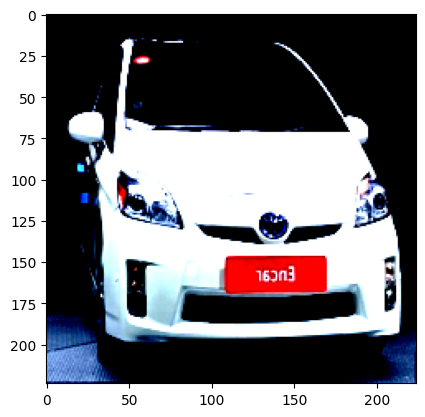

In [18]:
plt.imshow(images[sample_image].permute(1,2,0))
plt.show()

# Model Training and Hyperparameter Tuning

In [19]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        
        self.model = models.resnet50(weights='DEFAULT')
        
        # Freeze all layers except last fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        
        # Replace the fully connected layer
        
        in_features = self.model.fc.in_features
        
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features=in_features, out_features=num_classes)
        )
    
    def forward(self, x):
        x = self.model(x)
        return x

In [24]:
# Define objective function for Optuna

def objective(trial):
    # hyperparameters
    lr = trial.suggest_float('lr', 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.9)
    
    # load the model
    model = CarClassifierResNet(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    
    # define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    # training loop
    epochs = 5
    start = time.time()
    
    for epoch in range(epochs):
        
        model.train()
        running_loss = 0.0
        
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # zero the parameter gradients
            optimizer.zero_grad()
            
            # forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # backward pass and optimization
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
    
        epoch_loss = running_loss / len(train_loader.dataset)
    
        # Validation loop
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                
                _, predicted = torch.max(outputs.data, 1)
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        accuracy = 100 * correct / total
        
        # Report intermediate result to Optuna
        trial.report(accuracy, epoch)
            
        # Handle pruning
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    end = time.time()
    print(f"Execution Time: {end - start} seconds")
    
    return accuracy


In [26]:
# Create the optuna study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-03-28 23:18:38,308] A new study created in memory with name: no-name-c7c2885a-6436-401c-a293-6c37368f40fa
[I 2026-03-28 23:24:16,853] Trial 0 finished with value: 71.30434782608695 and parameters: {'lr': 2.0146124035119808e-05, 'dropout_rate': 0.12744621167065145}. Best is trial 0 with value: 71.30434782608695.


Execution Time: 338.0351903438568 seconds


[I 2026-03-28 23:30:43,823] Trial 1 finished with value: 77.91304347826087 and parameters: {'lr': 0.0005945273447481764, 'dropout_rate': 0.24919588049008007}. Best is trial 1 with value: 77.91304347826087.


Execution Time: 386.62068223953247 seconds


[I 2026-03-28 23:37:14,937] Trial 2 finished with value: 77.91304347826087 and parameters: {'lr': 0.003096882527698211, 'dropout_rate': 0.7594150955839776}. Best is trial 1 with value: 77.91304347826087.


...

[I 2026-03-28 23:59:05,140] Trial 7 pruned. 
[I 2026-03-29 00:00:22,084] Trial 8 pruned. 
[I 2026-03-29 00:07:00,312] Trial 9 finished with value: 79.65217391304348 and parameters: {'lr': 0.0014306206625680192, 'dropout_rate': 0.5694587495317042}. Best is trial 6 with value: 81.3913043478261.


Execution Time: 397.8655481338501 seconds


[I 2026-03-29 00:10:52,103] Trial 10 pruned. 
[I 2026-03-29 00:12:13,198] Trial 11 pruned. 
[I 2026-03-29 00:13:37,989] Trial 12 pruned. 
[I 2026-03-29 00:20:32,829] Trial 13 finished with value: 79.65217391304348 and parameters: {'lr': 0.0008928283754310989, 'dropout_rate': 0.4913363663849725}. Best is trial 6 with value: 81.3913043478261.


Execution Time: 414.43381547927856 seconds


[I 2026-03-29 00:22:11,110] Trial 14 pruned. 
[I 2026-03-29 00:23:47,189] Trial 15 pruned. 
[I 2026-03-29 00:25:21,320] Trial 16 pruned. 
[I 2026-03-29 00:26:57,977] Trial 17 pruned. 
[I 2026-03-29 00:28:35,050] Trial 18 pruned. 
[I 2026-03-29 00:33:18,119] Trial 19 pruned. 


In [27]:
study.best_params

{'lr': 0.0005255627371487033, 'dropout_rate': 0.29422958901218027}